In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision import transforms
import torch.nn.functional as F

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms.functional as F1
import torchvision.transforms as transforms
from PIL import Image
import cv2

# Custom dataset class for retinal images
class RetinalDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image, mask = self.transform(image, mask)

        mask = (mask > 0.5).float()  # Ensure mask is binary
        return image, mask

# Define training transformations
def train_transform(image, mask):
    image = F1.resize(image, (512, 512))
    mask = F1.resize(mask, (512, 512))

    if random.random() > 0.5:
        image = F1.hflip(image)
        mask = F1.hflip(mask)
    if random.random() > 0.3:
        image = F1.vflip(image)
        mask = F1.vflip(mask)
    angle = random.uniform(-15, 15)
    image = F1.rotate(image, angle)
    mask = F1.rotate(mask, angle)

    image = F1.to_tensor(image)
    mask = F1.to_tensor(mask).round()
    normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    image = normalize(image)

    return image, mask

# Define testing transformations (no augmentations)
def test_transform(image, mask):
    image = F1.resize(image, (512, 512))
    mask = F1.resize(mask, (512, 512))

    image = F1.to_tensor(image)
    mask = F1.to_tensor(mask).round()
    normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    image = normalize(image)

    return image, mask

# Load the DRIVE dataset
drive_train_dataset = RetinalDataset('/content/drive/MyDrive/dd/DRIVE/training/images', '/content/drive/MyDrive/dd/DRIVE/training/1st_manual', transform=train_transform)
drive_test_dataset = RetinalDataset('/content/drive/MyDrive/dd/DRIVE/test/images', '/content/drive/MyDrive/dd/DRIVE/test/1st_manual', transform=test_transform)

# Load the CHASE_DB dataset
chase_train_dataset = RetinalDataset('/content/drive/MyDrive/dd/chase/training/images', '/content/drive/MyDrive/dd/chase/training/1st_manual', transform=train_transform)
chase_test_dataset = RetinalDataset('/content/drive/MyDrive/dd/chase/test/images', '/content/drive/MyDrive/dd/chase/test/1st_manual', transform=test_transform)

# Combine training datasets of DRIVE and CHASE_DB
combined_train_dataset = ConcatDataset([drive_train_dataset, chase_train_dataset])

# Create data loaders for the combined training set and the individual test sets
train_loader = DataLoader(combined_train_dataset, batch_size=4, shuffle=True)
drive_test_loader = DataLoader(drive_test_dataset, batch_size=4, shuffle=False)
chase_test_loader = DataLoader(chase_test_dataset, batch_size=4, shuffle=False)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()
        self.encoder1 = self.conv_block(in_channels, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)
        self.encoder4 = self.conv_block(256, 512)

        self.bottleneck = self.conv_block(512, 1024)

        self.decoder4 = self.conv_block(1024 + 512, 512)
        self.decoder3 = self.conv_block(512 + 256, 256)
        self.decoder2 = self.conv_block(256 + 128, 128)
        self.decoder1 = self.conv_block(128 + 64, 64)

        self.final_layer = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(F.max_pool2d(e1, 2))
        e3 = self.encoder3(F.max_pool2d(e2, 2))
        e4 = self.encoder4(F.max_pool2d(e3, 2))

        b = self.bottleneck(F.max_pool2d(e4, 2))

        b_upsampled = F.interpolate(b, size=(e4.size(2), e4.size(3)), mode='bilinear', align_corners=True)
        d4 = self.decoder4(torch.cat((e4, b_upsampled), 1))
        d4_upsampled = F.interpolate(d4, size=(e3.size(2), e3.size(3)), mode='bilinear', align_corners=True)
        d3 = self.decoder3(torch.cat((e3, d4_upsampled), 1))
        d3_upsampled = F.interpolate(d3, size=(e2.size(2), e2.size(3)), mode='bilinear', align_corners=True)
        d2 = self.decoder2(torch.cat((e2, d3_upsampled), 1))
        d2_upsampled = F.interpolate(d2, size=(e1.size(2), e1.size(3)), mode='bilinear', align_corners=True)
        d1 = self.decoder1(torch.cat((e1, d2_upsampled), 1))
        out = self.final_layer(d1)
        return out
if __name__ == "__main__":
    x = torch.randn((2, 3, 512, 512))
    model = UNet(in_channels=3, out_channels=1)
    y = model(x)
    print(y.shape)

torch.Size([2, 1, 512, 512])


In [ ]:
# Define Res U-Net Model
class ResUNet(nn.Module):
  def __init__(self, in_channels, out_channels):
    super(ResUNet, self).__init__()
    self.encoder1 = self.res_block(in_channels, 64)
    self.encoder2 = self.res_block(64, 128)
    self.encoder3 = self.res_block(128, 256)
    self.encoder4 = self.res_block(256, 512)

    self.bottleneck = self.res_block(512, 1024)

    self.decoder4 = self.res_block(1024 + 512, 512)
    self.decoder3 = self.res_block(512 + 256, 256)
    self.decoder2 = self.res_block(256 + 128, 128)
    self.decoder1 = self.res_block(128 + 64, 64)

    self.final_layer = nn.Conv2d(64, out_channels, kernel_size=1)
    self.match1 = nn.Conv2d(in_channels, 64, kernel_size=1) if in_channels != 64 else nn.Identity()
    self.match2 = nn.Conv2d(64, 128, kernel_size=1)
    self.match3 = nn.Conv2d(128, 256, kernel_size=1)
    self.match4 = nn.Conv2d(256, 512, kernel_size=1)

  def res_block(self, in_channels, out_channels):
    return nn.Sequential(
      nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
      nn.BatchNorm2d(out_channels),
      nn.ReLU(inplace=True),
      nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
      nn.BatchNorm2d(out_channels),
      nn.ReLU(inplace=True),
      nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
      nn.BatchNorm2d(out_channels),
      nn.ReLU(inplace=True)
      )
  def forward(self, x):

    e1 = self.encoder1(x)
    e1 = e1 + self.match1(x)  # Match dimensions with 1x1 convolution
    e2 = self.encoder2(F.max_pool2d(e1, 2))
    e2 = e2 + self.match2(F.max_pool2d(e1, 2))
    e3 = self.encoder3(F.max_pool2d(e2, 2))
    e3 = e3 + self.match3(F.max_pool2d(e2, 2))
    e4 = self.encoder4(F.max_pool2d(e3, 2))
    e4 = e4 + self.match4(F.max_pool2d(e3, 2))
    b = self.bottleneck(F.max_pool2d(e4, 2))
    d4 = self.decoder4(torch.cat((e4, F.interpolate(b, scale_factor=2, mode='bilinear', align_corners=True)), 1))
    d3 = self.decoder3(torch.cat((e3, F.interpolate(d4, scale_factor=2, mode='bilinear', align_corners=True)), 1))
    d2 = self.decoder2(torch.cat((e2, F.interpolate(d3, scale_factor=2, mode='bilinear', align_corners=True)), 1))
    d1 = self.decoder1(torch.cat((e1, F.interpolate(d2, scale_factor=2, mode='bilinear', align_corners=True)), 1))

    out = self.final_layer(d1)
    return out
if __name__ == "__main__":
  x = torch.randn((2, 3, 512, 512))
  model = ResUNet(in_channels=3, out_channels=1)
  y = model(x)
  print(y.shape)

torch.Size([2, 1, 512, 512])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define Squeeze-and-Excitation Block
class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SqueezeExcitation, self).__init__()
        self.fc1 = nn.Linear(channels, channels // reduction, bias=False)
        self.fc2 = nn.Linear(channels // reduction, channels, bias=False)

    def forward(self, x):
        batch_size, channels, _, _ = x.size()
        y = F.adaptive_avg_pool2d(x, 1).view(batch_size, channels)
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y)).view(batch_size, channels, 1, 1)
        return x * y.expand_as(x)

# Define Attention Module
class AttentionModule(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(AttentionModule, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        attn_map = self.sigmoid(self.conv(x))
        return x * attn_map

# Define Res U-Net Model with Atrous Convolutions and Attention Module
class ResUNetWithAttentionAtrous(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResUNetWithAttentionAtrous, self).__init__()
        self.encoder1 = self.res_block(in_channels, 64)
        self.encoder2 = self.res_block(64, 128)
        self.encoder3 = self.res_block(128, 256)
        self.encoder4 = self.res_block(256, 512)

        # Squeeze-and-Excitation blocks
        self.se1 = SqueezeExcitation(64)
        self.se2 = SqueezeExcitation(128)
        self.se3 = SqueezeExcitation(256)
        self.se4 = SqueezeExcitation(512)

        # Bottleneck with Atrous Convolution
        self.bottleneck = self.atrous_block(512, 1024, dilation=2)

        self.decoder4 = self.res_block(1024 + 512, 512)
        self.decoder3 = self.res_block(512 + 256, 256)
        self.decoder2 = self.res_block(256 + 128, 128)
        self.decoder1 = self.res_block(128 + 64, 64)

        # Attention module before the final layer
        self.attention = AttentionModule(64, 64)

        self.final_layer = nn.Conv2d(64, out_channels, kernel_size=1)

        # 1x1 convolutions for matching dimensions
        self.match1 = nn.Conv2d(in_channels, 64, kernel_size=1) if in_channels != 64 else nn.Identity()
        self.match2 = nn.Conv2d(64, 128, kernel_size=1)
        self.match3 = nn.Conv2d(128, 256, kernel_size=1)
        self.match4 = nn.Conv2d(256, 512, kernel_size=1)

    def res_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def atrous_block(self, in_channels, out_channels, dilation):
        # Atrous (dilated) convolution for larger receptive fields
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        e1 = self.encoder1(x)
        e1 = e1 + self.match1(x)  # Match dimensions with 1x1 convolution
        e1 = self.se1(e1)  # Apply SE block

        e2 = self.encoder2(F.max_pool2d(e1, 2))
        e2 = e2 + self.match2(F.max_pool2d(e1, 2))
        e2 = self.se2(e2)  # Apply SE block

        e3 = self.encoder3(F.max_pool2d(e2, 2))
        e3 = e3 + self.match3(F.max_pool2d(e2, 2))
        e3 = self.se3(e3)  # Apply SE block

        e4 = self.encoder4(F.max_pool2d(e3, 2))
        e4 = e4 + self.match4(F.max_pool2d(e3, 2))
        e4 = self.se4(e4)  # Apply SE block

        # Bottleneck with Atrous Convolution
        b = self.bottleneck(F.max_pool2d(e4, 2))

        # Decoder
        d4 = self.decoder4(torch.cat((e4, F.interpolate(b, scale_factor=2, mode='bilinear', align_corners=True)), 1))
        d3 = self.decoder3(torch.cat((e3, F.interpolate(d4, scale_factor=2, mode='bilinear', align_corners=True)), 1))
        d2 = self.decoder2(torch.cat((e2, F.interpolate(d3, scale_factor=2, mode='bilinear', align_corners=True)), 1))
        d1 = self.decoder1(torch.cat((e1, F.interpolate(d2, scale_factor=2, mode='bilinear', align_corners=True)), 1))

        # Apply attention before the final output
        d1 = self.attention(d1)

        # Final output layer
        out = self.final_layer(d1)
        return out

if __name__ == "__main__":
    x = torch.randn((2, 3, 512, 512))  # Batch of 2, 3-channel (RGB) images of size 512x512
    model = ResUNetWithAttentionAtrous(in_channels=3, out_channels=1)  # Single channel output for segmentation
    y = model(x)
    print(y.shape)


torch.Size([2, 1, 512, 512])


In [ ]:
# Dice Coefficient
def dice_coefficient(pred, target, smooth=1e-6):
  pred = pred.contiguous()
  target = target.contiguous()
  intersection = (pred * target).sum(dim=2).sum(dim=2)
  dice = (2. * intersection + smooth) / (pred.sum(dim=2).sum(dim=2) + target.sum(dim=2).sum(dim=2) + smooth)
  return dice.mean()

In [ ]:
# Accuracy Metric
def accuracy(pred, target, threshold=0.5):
  pred = (pred > threshold).float()
  correct = (pred == target).float().sum()
  acc = correct / target.numel()
  return acc

In [ ]:
# Dice BCE Loss Class
class DiceBCELoss(nn.Module):
  def __init__(self, weight=None, size_average=True):
    super(DiceBCELoss, self).__init__()

  def forward(self, inputs, targets, smooth=1e-6):
        # Flatten
    inputs = torch.sigmoid(inputs)
    intersection = (inputs * targets).sum()
    dice_loss = 1 - (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
    BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')
    Dice_BCE = BCE + dice_loss
    return Dice_BCE

In [ ]:
import torch
import torch.nn as nn

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        """
        Focal Loss with alpha balancing factor and gamma focusing parameter.

        Args:
            alpha (float): balancing factor (usually 1 for binary classification).
            gamma (float): focusing parameter (adjusts the rate at which easy examples are down-weighted).
            reduction (str): Specifies the reduction to apply to the output: 'none' | 'mean' | 'sum'.
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # Convert logits to probabilities
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-BCE_loss)  # pt is the probability that the model assigns to the correct class

        # Focal loss calculation
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss

        if self.reduction == 'mean':
            return F_loss.mean()
        elif self.reduction == 'sum':
            return F_loss.sum()
        else:
            return F_loss


In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.2/869.2 kB 26.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import torch.optim as optim
import torchmetrics

# Modified train_model function
def train_model(model, train_loader, test_loader, num_epochs=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = FocalLoss(alpha=1, gamma=2, reduction='mean')
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True, threshold=1e-4)

    # Store metrics for both training and testing
    metrics = {
        'train': {'loss': [], 'dice': [], 'acc': [], 'prec': [], 'rec': []},
        'test': {'dice': [], 'acc': [], 'prec': [], 'rec': []}
    }

    for epoch in range(num_epochs):
        model.train()
        epoch_train_metrics = {'loss': 0, 'dice': 0, 'acc': 0, 'prec': 0, 'rec': 0}

        for img, mask in train_loader:
            img, mask = img.to(device), mask.to(device)
            optimizer.zero_grad()
            output = model(img)
            loss = criterion(output, mask)
            loss.backward()
            optimizer.step()

            # Apply sigmoid for prediction
            output_sigmoid = torch.sigmoid(output)
            pred_binary = (output_sigmoid > 0.5).float()

            # Calculate metrics
            epoch_train_metrics['loss'] += loss.item()
            epoch_train_metrics['dice'] += dice_coefficient(pred_binary, mask).item()
            epoch_train_metrics['acc'] += accuracy(pred_binary, mask).item()
            epoch_train_metrics['prec'] += torchmetrics.functional.precision(pred_binary, mask, task='binary').item()
            epoch_train_metrics['rec'] += torchmetrics.functional.recall(pred_binary, mask, task='binary').item()

        # Average the training metrics
        for key in epoch_train_metrics:
            epoch_train_metrics[key] /= len(train_loader)

        for key in epoch_train_metrics:
            metrics['train'][key].append(epoch_train_metrics[key])

        # Test phase
        model.eval()
        epoch_test_metrics = {'dice': 0, 'acc': 0, 'prec': 0, 'rec': 0}

        with torch.no_grad():
            for img, mask in test_loader:
                img, mask = img.to(device), mask.to(device)
                output = model(img)
                output_sigmoid = torch.sigmoid(output)
                pred_binary = (output_sigmoid > 0.5).float()

                # Calculate test metrics
                epoch_test_metrics['dice'] += dice_coefficient(pred_binary, mask).item()
                epoch_test_metrics['acc'] += accuracy(pred_binary, mask).item()
                epoch_test_metrics['prec'] += torchmetrics.functional.precision(pred_binary, mask, task='binary').item()
                epoch_test_metrics['rec'] += torchmetrics.functional.recall(pred_binary, mask, task='binary').item()

        # Average the test metrics
        for key in epoch_test_metrics:
            epoch_test_metrics[key] /= len(test_loader)

        for key in epoch_test_metrics:
            metrics['test'][key].append(epoch_test_metrics[key])

        scheduler.step(epoch_train_metrics['loss'])

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_train_metrics["loss"]:.4f}, Train Dice: {epoch_train_metrics["dice"]:.4f}, Test Dice: {epoch_test_metrics["dice"]:.4f}')

    # Create a DataFrame to summarize the metrics
    train_metrics_df = pd.DataFrame(metrics['train'])
    test_metrics_df = pd.DataFrame(metrics['test'])

    # Adding epoch column for better tracking
    train_metrics_df['epoch'] = range(1, num_epochs + 1)
    test_metrics_df['epoch'] = range(1, num_epochs + 1)

    # Display the DataFrames
    print("Training Metrics:\n", train_metrics_df)
    print("Testing Metrics:\n", test_metrics_df)

    return metrics


In [ ]:
def plot_model_comparison(metrics_unet, metrics_resunet, metric_name):
    epochs = range(1, len(metrics_unet) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, metrics_unet, 'b', label='U-Net')
    plt.plot(epochs, metrics_resunet, 'r', label='ResU-Net')
    plt.title(f'{metric_name} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(metric_name)
    plt.legend()
plt.show()

In [ ]:
def visualize_model_comparisons(unet_model, resunet_model, resunet_attention_model, dataloader, device='cuda', num_images=5):
    unet_model.eval()
    resunet_model.eval()
    resunet_attention_model.eval()

    models = [unet_model, resunet_model, resunet_attention_model]
    titles = ['U-Net', 'ResU-Net', 'ResU-Net with Attention & Atrous']

    images, masks = next(iter(dataloader))
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = [torch.sigmoid(model(images)).cpu() for model in models]

    images = images.cpu()
    masks = masks.cpu()

    fig, ax = plt.subplots(num_images, 5, figsize=(20, 5 * num_images))
    for i in range(num_images):
        # Input Image
        ax[i, 0].imshow(images[i].permute(1, 2, 0).numpy())
        ax[i, 0].set_title('Input Image')
        ax[i, 0].axis('off')

        # Ground Truth
        ax[i, 1].imshow(masks[i].squeeze().numpy(), cmap='gray')
        ax[i, 1].set_title('Ground Truth')
        ax[i, 1].axis('off')

        # Predictions from each model
        for j in range(3):
            ax[i, j + 2].imshow((outputs[j][i] > 0.4).float().squeeze().numpy(), cmap='gray')
            ax[i, j + 2].set_title(titles[j])
            ax[i, j + 2].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np

def plot_model_comparison(train_metric_unet, test_metric_unet,
                          train_metric_resunet, test_metric_resunet,
                          train_metric_resunet_attention, test_metric_resunet_attention,
                          metric_name):
    epochs = range(1, len(train_metric_unet) + 1)

    fig, axs = plt.subplots(2, 1, figsize=(12, 14))

    # Training Metrics Plot
    axs[0].plot(epochs, train_metric_unet, 'b-o', label=f'U-Net Train {metric_name}', markersize=5)
    axs[0].plot(epochs, train_metric_resunet, 'g-o', label=f'ResU-Net Train {metric_name}', markersize=5)
    axs[0].plot(epochs, train_metric_resunet_attention, 'm-o', label=f'ResU-Net (Att) Train {metric_name}', markersize=5)

    # Highlight max accuracy
    max_train_unet = np.max(train_metric_unet)
    axs[0].annotate(f'Max: {max_train_unet:.3f}', xy=(epochs[np.argmax(train_metric_unet)], max_train_unet),
                    xytext=(epochs[np.argmax(train_metric_unet)], max_train_unet + 0.02),
                    arrowprops=dict(arrowstyle='->'), fontsize=10, color='b')

    max_train_resunet = np.max(train_metric_resunet)
    axs[0].annotate(f'Max: {max_train_resunet:.3f}', xy=(epochs[np.argmax(train_metric_resunet)], max_train_resunet),
                    xytext=(epochs[np.argmax(train_metric_resunet)], max_train_resunet + 0.02),
                    arrowprops=dict(arrowstyle='->'), fontsize=10, color='g')

    max_train_resunet_att = np.max(train_metric_resunet_attention)
    axs[0].annotate(f'Max: {max_train_resunet_att:.3f}', xy=(epochs[np.argmax(train_metric_resunet_attention)], max_train_resunet_att),
                    xytext=(epochs[np.argmax(train_metric_resunet_attention)], max_train_resunet_att + 0.02),
                    arrowprops=dict(arrowstyle='->'), fontsize=10, color='m')

    axs[0].set_title(f'Training {metric_name} Over Epochs', fontsize=14)
    axs[0].set_xlabel('Epochs', fontsize=12)
    axs[0].set_ylabel(metric_name, fontsize=12)
    axs[0].legend(fontsize=12)
    axs[0].grid(True)

    # Testing Metrics Plot
    axs[1].plot(epochs, test_metric_unet, 'r-o', label=f'U-Net Test {metric_name}', markersize=5)
    axs[1].plot(epochs, test_metric_resunet, 'k-o', label=f'ResU-Net Test {metric_name}', markersize=5)
    axs[1].plot(epochs, test_metric_resunet_attention, 'c-o', label=f'ResU-Net (Att) Test {metric_name}', markersize=5)

    # Highlight max accuracy
    max_test_unet = np.max(test_metric_unet)
    axs[1].annotate(f'Max: {max_test_unet:.3f}', xy=(epochs[np.argmax(test_metric_unet)], max_test_unet),
                    xytext=(epochs[np.argmax(test_metric_unet)], max_test_unet - 0.1),
                    arrowprops=dict(arrowstyle='->'), fontsize=10, color='r')

    max_test_resunet = np.max(test_metric_resunet)
    axs[1].annotate(f'Max: {max_test_resunet:.3f}', xy=(epochs[np.argmax(test_metric_resunet)], max_test_resunet),
                    xytext=(epochs[np.argmax(test_metric_resunet)], max_test_resunet - 0.1),
                    arrowprops=dict(arrowstyle='->'), fontsize=10, color='k')

    max_test_resunet_att = np.max(test_metric_resunet_attention)
    axs[1].annotate(f'Max: {max_test_resunet_att:.3f}', xy=(epochs[np.argmax(test_metric_resunet_attention)], max_test_resunet_att),
                    xytext=(epochs[np.argmax(test_metric_resunet_attention)], max_test_resunet_att - 0.1),
                    arrowprops=dict(arrowstyle='->'), fontsize=10, color='c')

    axs[1].set_title(f'Testing {metric_name} Over Epochs', fontsize=14)
    axs[1].set_xlabel('Epochs', fontsize=12)
    axs[1].set_ylabel(metric_name, fontsize=12)
    axs[1].legend(fontsize=12)
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
# Initialize models
unet_model = UNet(in_channels=3, out_channels=1)
resunet_model = ResUNet(in_channels=3, out_channels=1)
resunet_attention_model = ResUNetWithAttentionAtrous(in_channels=3, out_channels=1)

In [ ]:
print("Training UNet..........")
unet_metrics = train_model(unet_model, train_loader, drive_test_loader, num_epochs=100)

print("Training ResUNet..........")
resunet_metrics = train_model(resunet_model, train_loader, drive_test_loader, num_epochs=100)

print("Training ResUnetWithAttentionAtrous..........")
resunet_attention_metrics = train_model(resunet_attention_model, train_loader, drive_test_loader, num_epochs=100)

Training UNet..........


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 10/100, Loss: 0.0519, Train Dice: 0.4441, Test Dice: 0.3929
Epoch 20/100, Loss: 0.0367, Train Dice: 0.6679, Test Dice: 0.6980
Epoch 30/100, Loss: 0.0333, Train Dice: 0.6962, Test Dice: 0.6195
Epoch 40/100, Loss: 0.0306, Train Dice: 0.7187, Test Dice: 0.5617
Epoch 50/100, Loss: 0.0290, Train Dice: 0.7317, Test Dice: 0.5684
Epoch 60/100, Loss: 0.0286, Train Dice: 0.7363, Test Dice: 0.5645
Epoch 70/100, Loss: 0.0284, Train Dice: 0.7366, Test Dice: 0.5621
Epoch 80/100, Loss: 0.0283, Train Dice: 0.7385, Test Dice: 0.5627
Epoch 90/100, Loss: 0.0280, Train Dice: 0.7418, Test Dice: 0.5720
Epoch 100/100, Loss: 0.0280, Train Dice: 0.7393, Test Dice: 0.5692
Training Metrics:
         loss      dice       acc      prec       rec  epoch
0   0.177281  0.130124  0.659359  0.099819  0.353406      1
1   0.099622  0.058850  0.903890  0.143306  0.043677      2
2   0.081169  0.017781  0.918226  0.161351  0.010338      3
3   0.074387  0.012230  0.919727  0.182742  0.006737      4
4   0.069749  0.0117

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 10/100, Loss: 0.0405, Train Dice: 0.6110, Test Dice: 0.5503
Epoch 20/100, Loss: 0.0320, Train Dice: 0.6948, Test Dice: 0.7441


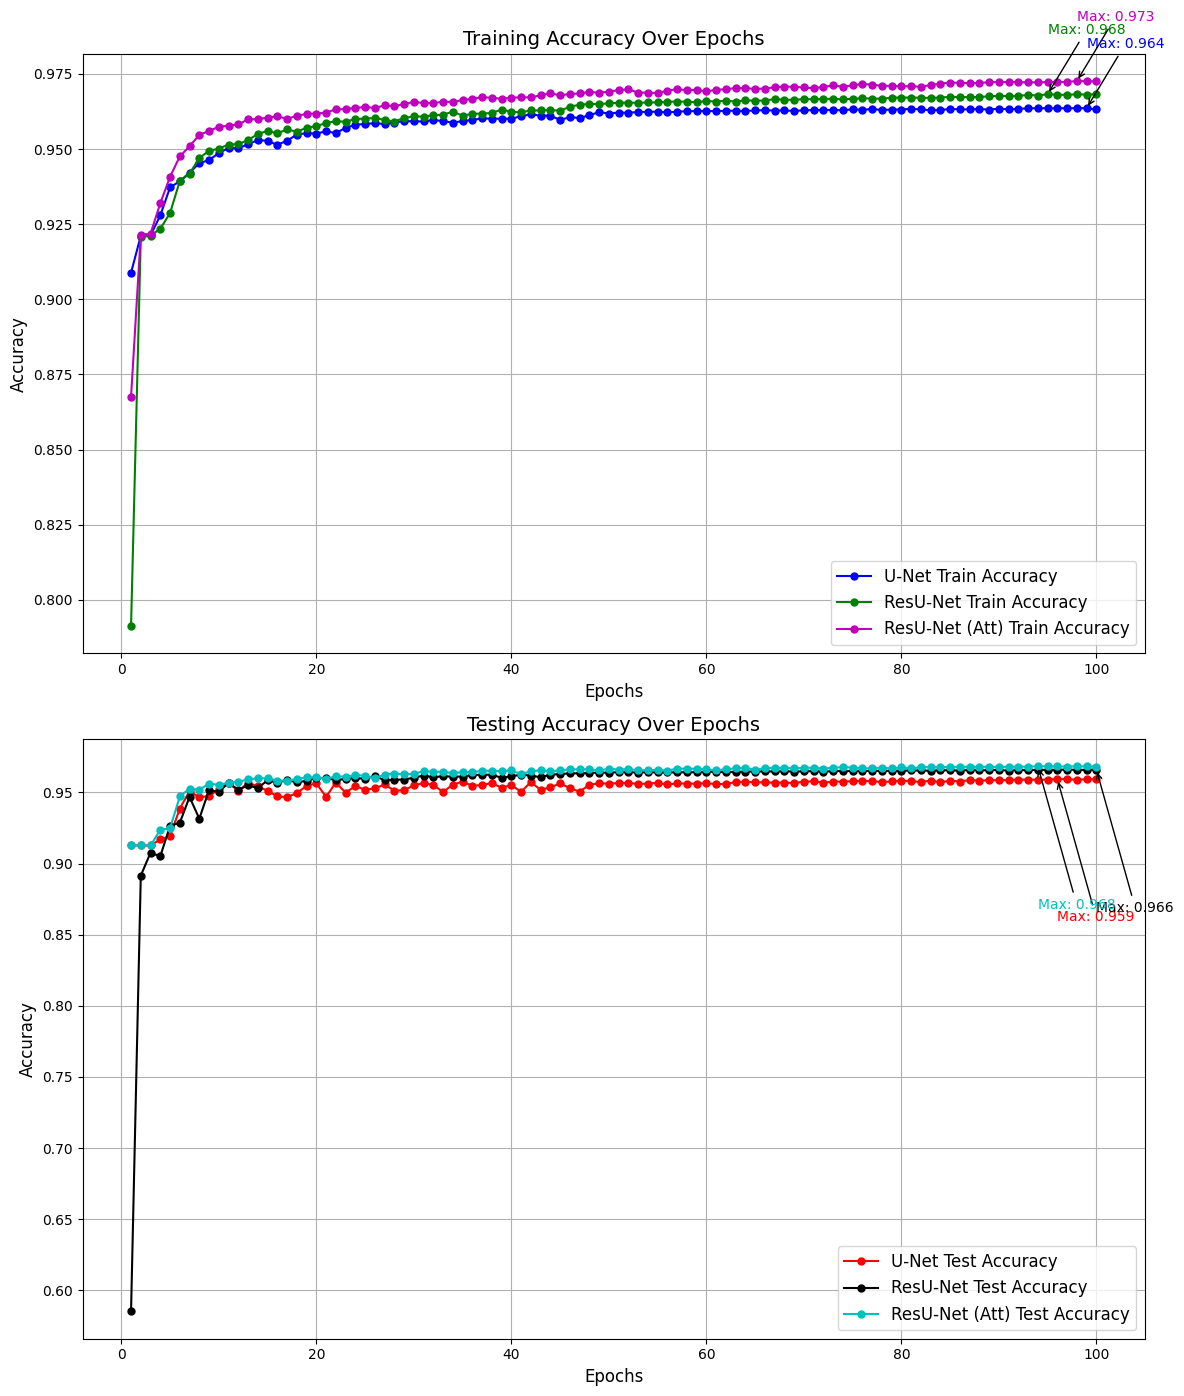

In [ ]:
# Plot for Accuracy
plot_model_comparison(unet_metrics['train']['acc'], unet_metrics['test']['acc'],
                      resunet_metrics['train']['acc'], resunet_metrics['test']['acc'],
                      resunet_attention_metrics['train']['acc'], resunet_attention_metrics['test']['acc'],
                      'Accuracy')

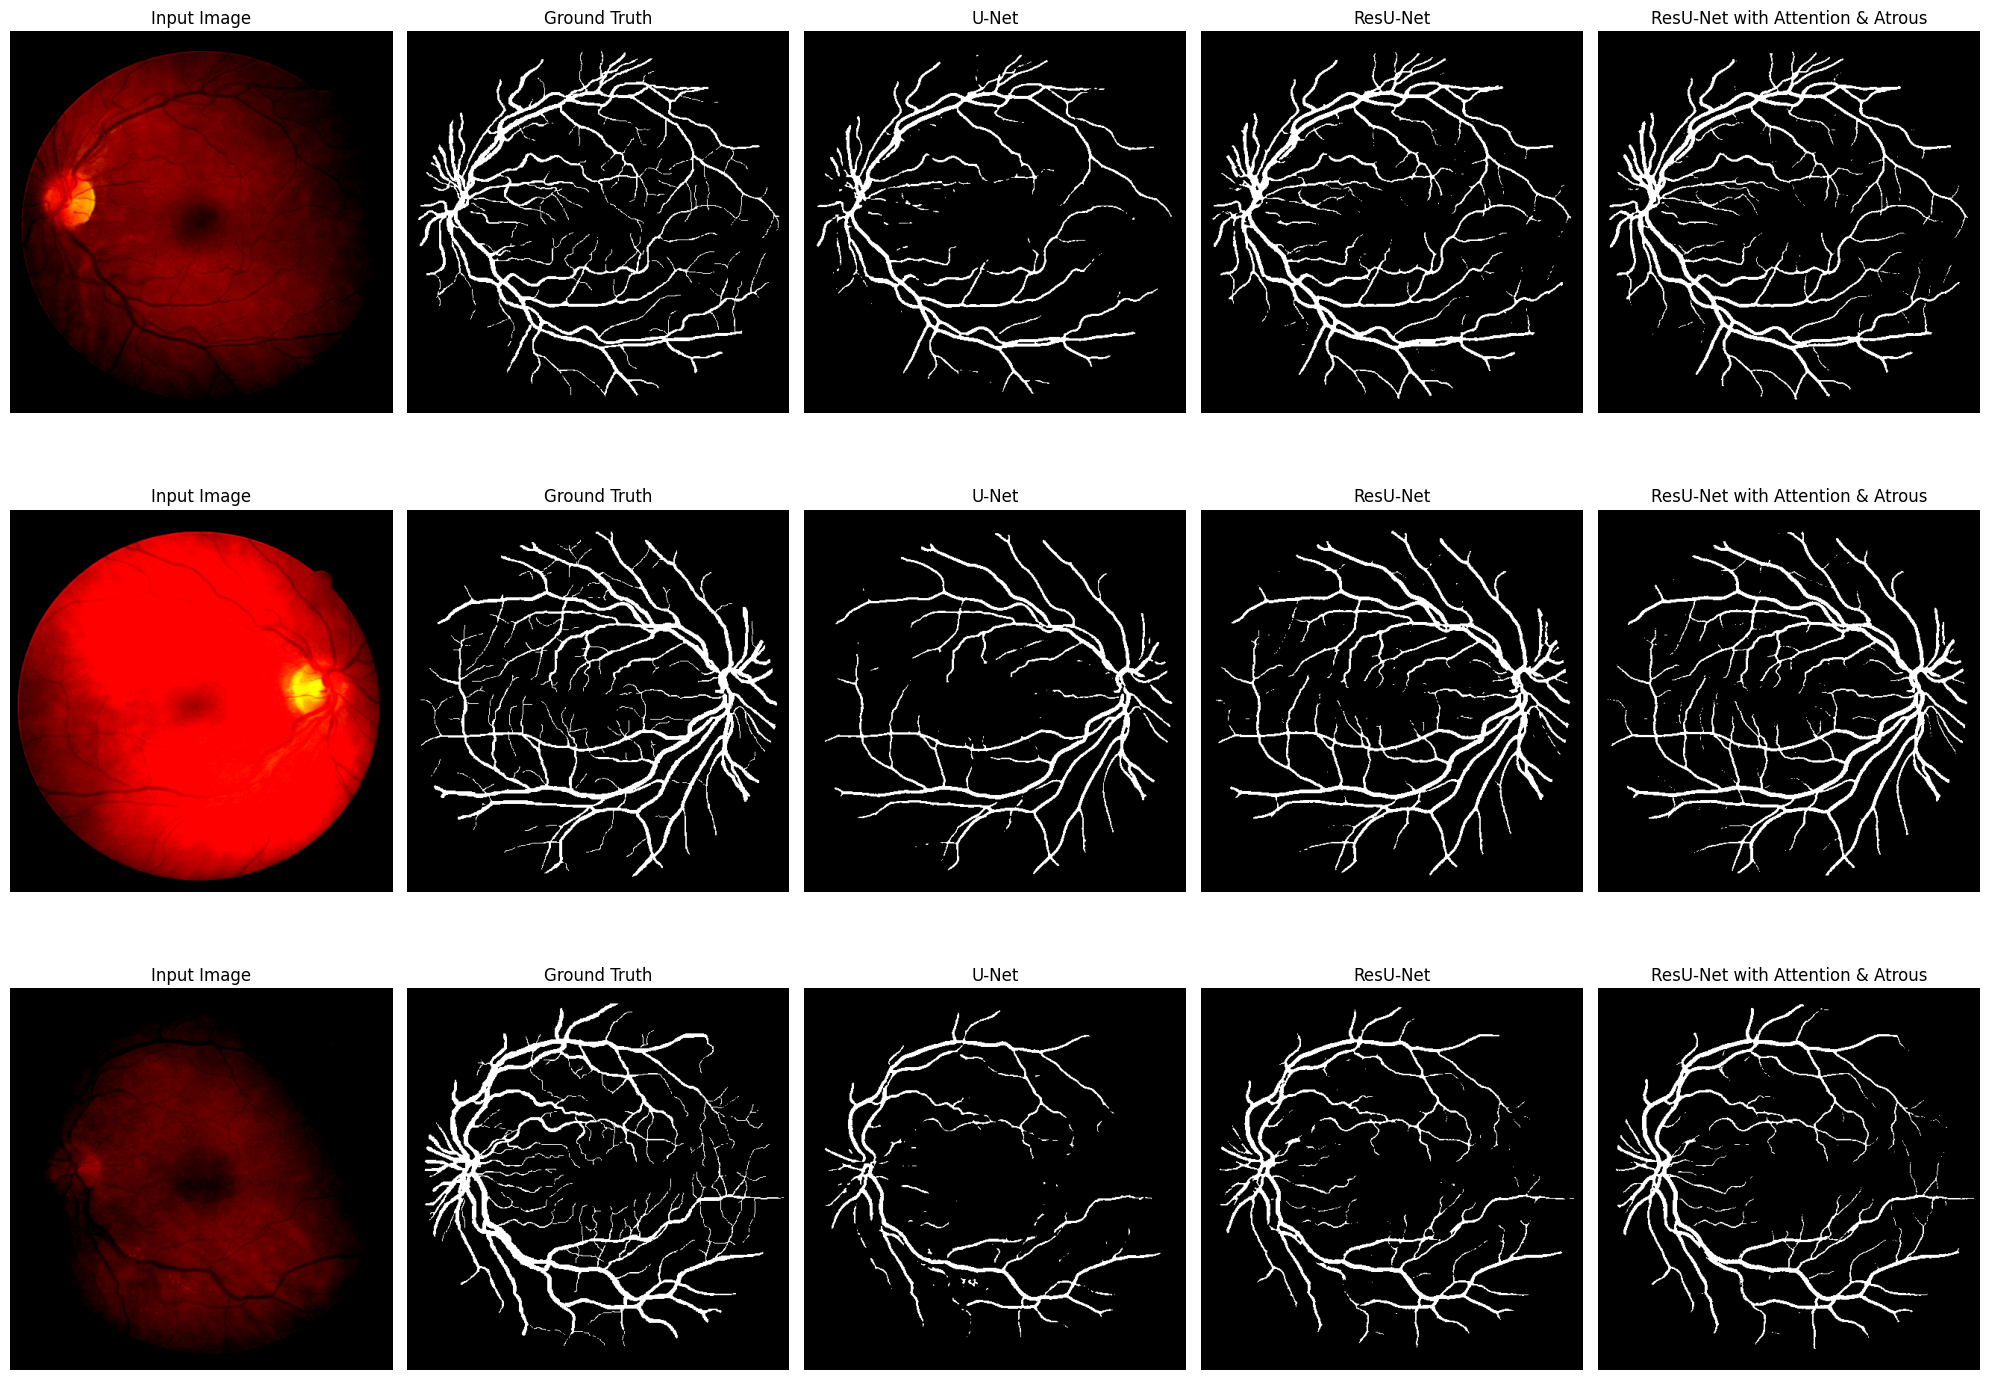

In [ ]:
visualize_model_comparisons(unet_model, resunet_model, resunet_attention_model, drive_test_loader, device='cuda', num_images=3)
